# Evaluate the RC/RGB evolutionary-state classifier

Robustness diagnostics for the classifier in `scripts/apply_rgb_ages.py`,
beyond the single CV line it logs:

1. **Baseline stratified CV** -- out-of-fold probabilities, purity/completeness
   vs. threshold, and where in the Kiel diagram the mistakes live.
2. **Calibration & stability** -- is `p > MIN_PROBA` meaningful, and how much
   does `p` move between fold models?
3. **Shifted holdouts** -- train on metal-poor / high-SNR stars, test on the
   metal-rich / low-SNR tail. The gap to the random-CV number on the *same*
   test stars is the extrapolation penalty (the thing the logged CV can't see).
4. **Noise degradation** -- accuracy vs. injected spectral noise, simulating a
   lower-SNR target sample (e.g. the bulge).
5. **Feature-mode comparison** -- labels vs. spectra vs. both.
6. **Out-of-support check** -- how far outside the training label space a
   target sample sits.

States: `1 = RGB` (first ascent), `2 = HeB` (red clump).

In [1]:
# --- JAX backend selection with CPU fallback (same probe as train_rgb) ---
# The continuum normalization runs on JAX; a tiny matmul checks the GPU
# backend can actually COMPILE, falling back to CPU otherwise.
import jax
import jax.numpy as jnp

try:
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()
    print("JAX backend:", jax.default_backend())
except Exception as exc:
    print(f"GPU compile failed ({type(exc).__name__}) -- falling back to CPU")
    jax.config.update("jax_default_device", jax.devices("cpu")[0])
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()

E0730 21:52:01.686716 2348035 cuda_executor.cc:1182] [0] Failed to allocate device memory of 29.76GiB (31952207872 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0730 21:52:01.686984 2348035 cuda_executor.cc:1182] [0] Failed to allocate device memory of 26.78GiB (28756985856 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0730 21:52:01.687212 2348035 cuda_executor.cc:1182] [0] Failed to allocate device memory of 24.10GiB (25881286656 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0730 21:52:01.687434 2348035 cuda_executor.cc:1182] [0] Failed to allocate device memory of 21.69GiB (23293157376 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0730 21:52:01.687652 2348035 cuda_executor.cc:1182] [0] Failed to allocate device memory of 19.52GiB (20963842048 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0730 21:52:01.687868 2348035 cuda_executor.cc:1182] [0] Failed to allocate

JAX backend: gpu


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# scripts/ is not an installed package -- put the repo root on the path.
repo = Path('/home/100/mj8805/scr_mk27/AnniesLasso')
sys.path.insert(0, str(repo))

from scripts.apply_rgb_ages import (RGB, HEB, STATE_LABELS, EVO_FEATURES,
                                    CLASSIFIER_FEATURE_MODES,
                                    DEFAULT_SPECTRAL_COMPONENTS,
                                    seismic_state, classifier_matrix,
                                    _make_estimator)
from scripts.train_cannon import (load_spectra, normalize_spectra,
                                  quality_mask, add_x_fe_columns)

# Fixed categorical palette (validated adjacent pairs): the RGB keeps the
# warm hue used in the other notebooks, the clump the cool one.
C_RGB, C_HEB, C_AQUA = "#eb6834", "#2a78d6", "#1baf7a"
GRAY = "#52514e"

In [ ]:
SRC = Path("/home/100/mj8805/scr_mk27/")
DATA = SRC / "bulge-ages-and-orbits/data"

TRAIN_PATH = DATA / "merged_with_ages_raw.parquet"  # seismically labeled sample
CONTINUUM_LIST = DATA / "continuum.list"
# Optional target-population sample for the out-of-support check (only its
# label columns are used; the cell is skipped if the file does not exist).
TARGET_SAMPLE_PATH = DATA / "bulge_rgb_spectra.parquet"

FEATURES = "both"      # "labels" | "spectra" | "both" -- as passed to the script
N_COMPONENTS = DEFAULT_SPECTRAL_COMPONENTS
MIN_PROBA = 0.9        # acceptance threshold used in production
TARGET = RGB           # state whose purity/completeness we care about
N_SPLITS = 5
SEED = 0

## Load the labeled sample

Same pipeline as the script: quality cuts, seismic states from
`EvoState`/`EvolSt`, spectra continuum-normalized identically to training.
A per-star SNR proxy (median `flux * sqrt(ivar)` over good pixels of the raw
spectrum) is kept for the SNR holdout.

In [4]:
table, dispersion, flux, ivar = load_spectra(str(TRAIN_PATH))
keep = np.asarray(quality_mask(table), dtype=bool)
table, flux, ivar = table.loc[keep], flux[keep], ivar[keep]

state = seismic_state(table)
labeled = state.notna().to_numpy()
print(f"{keep.sum()} stars pass quality cuts; {labeled.sum()} seismically "
      f"labeled ({int((state == RGB).sum())} RGB, "
      f"{int((state == HEB).sum())} HeB)")

# Per-star SNR proxy from the raw spectra (before normalization).
with np.errstate(invalid="ignore"):
    snr = np.nanmedian(np.where(ivar > 0, flux * np.sqrt(ivar), np.nan),
                       axis=1)

normalized_flux, normalized_ivar = normalize_spectra(
    dispersion, flux, ivar, str(CONTINUUM_LIST))

2026-07-30 21:52:18,765 [INFO] derived [X/Fe] columns: al_fe, ca_fe, ce_fe, c_fe, co_fe, cr_fe, cu_fe, k_fe, mg_fe, mn_fe, na_fe, nd_fe, ni_fe, n_fe, o_fe, p_fe, si_fe, s_fe, ti_fe, v_fe
2026-07-30 21:52:20,747 [INFO] loaded 23708 stars x 8575 pixels
2026-07-30 21:52:20,750 [INFO] quality cut: 8416/23708 rejected by spectrum_flags_x != 0
2026-07-30 21:52:20,762 [INFO] quality cut: 10395/23708 stars left after rejecting any of warn_low_numax, warn_high_Dnu, warn_high_RUWE, warn_NSS, warn_APOGEE, warn_plax_err, warn_dustmaps, warn_nve_Av_Dnu, warn_nve_Av_L, warn_massdiff set
2026-07-30 21:52:20,764 [INFO] quality cut: 973/23708 rejected by flag_bad
2026-07-30 21:52:20,767 [INFO] quality cut: 697/23708 rejected by std_v_rad_x > 0.50 km/s


10079 stars pass quality cuts; 4925 seismically labeled (2024 RGB, 2901 HeB)


Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

2026-07-30 21:52:36,251 [INFO] median normalized flux on good pixels: 0.9832 (target ~1)
INFO:thecannon.train:median normalized flux on good pixels: 0.9832 (target ~1)


In [5]:
lab_table = table.loc[labeled]
y = state[labeled].to_numpy()
lab_flux = normalized_flux[labeled]
lab_ivar = normalized_ivar[labeled]
lab_snr = snr[labeled]
is_target = y == TARGET

X = classifier_matrix(lab_table, lab_flux, lab_ivar, FEATURES)
n_comp = int(min(N_COMPONENTS, lab_flux.shape[1], len(y) - 1))
print(f"feature matrix: {X.shape}, PCA components: {n_comp}")

feature matrix: (4925, 8581), PCA components: 50


## 1. Baseline stratified CV

The same estimator and folds as `_report_cv`, but keeping the per-star
out-of-fold probabilities so every later diagnostic reads off them.

In [6]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
splits = list(cv.split(X, y))
classes = np.unique(y)

proba_oof = cross_val_predict(_make_estimator(FEATURES, n_comp), X, y,
                              cv=cv, method="predict_proba")
p_target = proba_oof[:, list(classes).index(TARGET)]
pred = classes[proba_oof.argmax(axis=1)]
correct = pred == y

teff = lab_table["raw_teff"].to_numpy(dtype=float)
logg = lab_table["raw_logg"].to_numpy(dtype=float)
box = (logg > 2.2) & (logg < 2.7) & (teff > 4500) & (teff < 5100)

acc = float(correct.mean())
auc = float(roc_auc_score(is_target, p_target))
accepted = p_target > MIN_PROBA
print(f"accuracy {acc:.3f} | ROC AUC {auc:.3f}")
print(f"at p > {MIN_PROBA}: purity "
      f"{float((y[accepted] == TARGET).mean()):.3f}, completeness "
      f"{float(accepted[is_target].mean()):.3f} "
      f"({int(accepted.sum())}/{len(y)} accepted)")
print(f"clump-box accuracy (2.2 < logg < 2.7, 4500 < Teff < 5100 K): "
      f"{float(correct[box].mean()):.3f} (n={int(box.sum())})")

accuracy 0.938 | ROC AUC 0.977
at p > 0.9: purity 0.938, completeness 0.857 (1849/4925 accepted)
clump-box accuracy (2.2 < logg < 2.7, 4500 < Teff < 5100 K): 0.958 (n=2386)


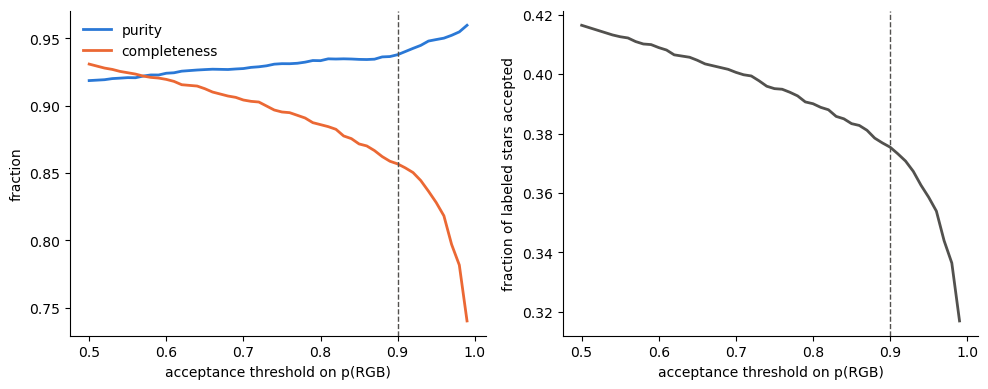

In [7]:
# Purity / completeness / accepted fraction as the threshold moves.
thresholds = np.linspace(0.5, 0.99, 50)
purity = np.array([float((y[p_target > t] == TARGET).mean())
                   if (p_target > t).any() else np.nan for t in thresholds])
completeness = np.array([float((p_target > t)[is_target].mean())
                         for t in thresholds])
frac_accepted = np.array([float((p_target > t).mean()) for t in thresholds])

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(thresholds, purity, color=C_HEB, lw=2, label="purity")
axes[0].plot(thresholds, completeness, color=C_RGB, lw=2,
             label="completeness")
axes[0].axvline(MIN_PROBA, color=GRAY, ls="--", lw=1)
axes[0].set_xlabel("acceptance threshold on p({})".format(
    STATE_LABELS[TARGET]))
axes[0].set_ylabel("fraction")
axes[0].legend(frameon=False)

axes[1].plot(thresholds, frac_accepted, color=GRAY, lw=2)
axes[1].axvline(MIN_PROBA, color=GRAY, ls="--", lw=1)
axes[1].set_xlabel("acceptance threshold on p({})".format(
    STATE_LABELS[TARGET]))
axes[1].set_ylabel("fraction of labeled stars accepted")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

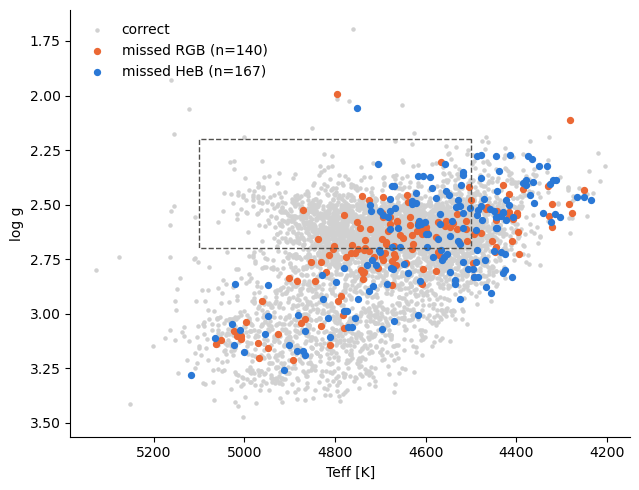

In [8]:
# Where the mistakes live: Kiel diagram, misclassified stars colored by
# their true state, the ambiguous clump box dashed.
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(teff[correct], logg[correct], s=5, c="0.82", label="correct")
for cls, color in ((RGB, C_RGB), (HEB, C_HEB)):
    m = ~correct & (y == cls)
    ax.scatter(teff[m], logg[m], s=18, c=color,
               label=f"missed {STATE_LABELS[cls]} (n={int(m.sum())})")
ax.add_patch(Rectangle((4500, 2.2), 600, 0.5, fill=False, edgecolor=GRAY,
                       ls="--", lw=1))
ax.set_xlabel("Teff [K]")
ax.set_ylabel("log g")
ax.invert_xaxis()
ax.invert_yaxis()
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## 2. Calibration & fold-to-fold stability

The `p > MIN_PROBA` gate is only meaningful if `p` is calibrated: in a
reliability diagram the curve should track the diagonal. If it sits above the
diagonal at high `p`, the classifier is under-confident (the threshold is
stricter than intended); below it, over-confident (accepted contamination is
higher than `1 - MIN_PROBA` suggests).

The right panel is a stability check: the same star scored by the five fold
models. A large spread near the threshold means acceptance is partly a seed
lottery -- an argument for a fold-ensemble (average `p`) in production. Note
each fold model saw ~4/5 of these stars in training, so the spread measures
model variance, not accuracy.

median fold spread: 0.000 overall, 0.042 within 0.05 of the threshold (n=122)


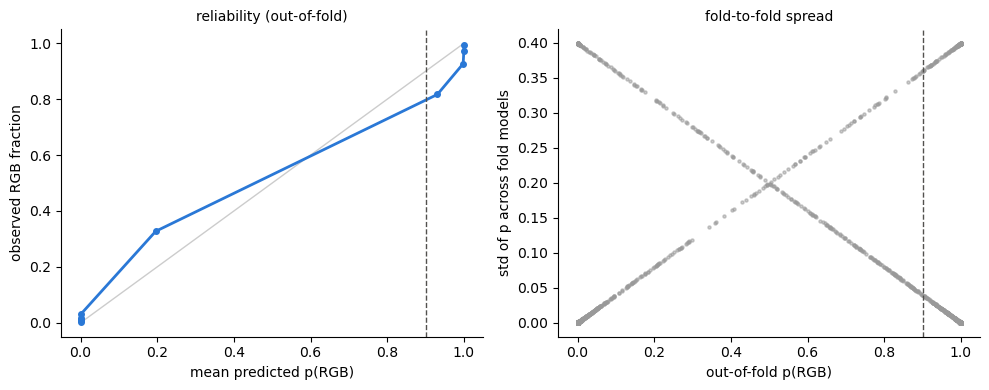

In [9]:
from sklearn.calibration import calibration_curve

fold_models = [_make_estimator(FEATURES, n_comp).fit(X[tr], y[tr])
               for tr, te in splits]
P = np.column_stack([
    m.predict_proba(X)[:, list(np.asarray(m.classes_)).index(TARGET)]
    for m in fold_models])
p_std = P.std(axis=1)

frac_pos, mean_pred = calibration_curve(is_target, p_target, n_bins=10,
                                        strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot([0, 1], [0, 1], color="0.8", lw=1)
axes[0].plot(mean_pred, frac_pos, color=C_HEB, lw=2, marker="o", ms=4)
axes[0].axvline(MIN_PROBA, color=GRAY, ls="--", lw=1)
axes[0].set_xlabel("mean predicted p({})".format(STATE_LABELS[TARGET]))
axes[0].set_ylabel("observed {} fraction".format(STATE_LABELS[TARGET]))
axes[0].set_title("reliability (out-of-fold)", fontsize=10)

axes[1].scatter(p_target, p_std, s=5, c="0.6", alpha=0.5)
axes[1].axvline(MIN_PROBA, color=GRAY, ls="--", lw=1)
axes[1].set_xlabel("out-of-fold p({})".format(STATE_LABELS[TARGET]))
axes[1].set_ylabel("std of p across fold models")
axes[1].set_title("fold-to-fold spread", fontsize=10)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

near = np.abs(p_target - MIN_PROBA) < 0.05
print(f"median fold spread: {np.median(p_std):.3f} overall, "
      f"{np.median(p_std[near]):.3f} within 0.05 of the threshold "
      f"(n={int(near.sum())})")

## 3. Shifted holdouts

Train on one side of a cut, test on the other -- deliberately breaking the
i.i.d. assumption the stratified CV relies on. `acc_random_cv` / `auc_random_cv`
are the baseline out-of-fold numbers restricted to the *same* test stars, so
the difference between columns is purely the cost of extrapolation.

The metallicity cuts mimic applying an APOKASC-trained classifier to a
metal-rich population (the bulge); the SNR cut mimics applying it to noisier
spectra. A large gap here is the warning the logged CV line cannot give.

In [10]:
feh = lab_table["raw_fe_h"].to_numpy(dtype=float)


def holdout_eval(train_mask, test_mask, tag):
    est = _make_estimator(FEATURES, n_comp).fit(X[train_mask], y[train_mask])
    proba = est.predict_proba(X[test_mask])
    cls = np.asarray(est.classes_)
    p = proba[:, list(cls).index(TARGET)]
    pred_h = cls[proba.argmax(axis=1)]
    yt = y[test_mask]
    acc_mask = p > MIN_PROBA
    row = {
        "holdout": tag,
        "n_train": int(train_mask.sum()),
        "n_test": int(test_mask.sum()),
        "acc_shifted": float((pred_h == yt).mean()),
        "acc_random_cv": float(correct[test_mask].mean()),
        "purity_at_thresh": (float((yt[acc_mask] == TARGET).mean())
                             if acc_mask.any() else np.nan),
        "completeness_at_thresh": float(acc_mask[yt == TARGET].mean()),
    }
    if len(np.unique(yt)) == 2:
        row["auc_shifted"] = float(roc_auc_score(yt == TARGET, p))
        row["auc_random_cv"] = float(
            roc_auc_score(yt == TARGET, p_target[test_mask]))
    return row


rows = []
for q in (0.6, 0.7, 0.8):
    cut = float(np.nanquantile(feh, q))
    rows.append(holdout_eval(feh <= cut, feh > cut,
                             f"[Fe/H] > {cut:+.2f} (top {100 * (1 - q):.0f}%)"))
snr_lo, snr_hi = np.nanquantile(lab_snr, [0.25, 0.5])
rows.append(holdout_eval(lab_snr >= snr_hi, lab_snr < snr_lo,
                         f"SNR < {snr_lo:.0f} (trained on SNR >= {snr_hi:.0f})"))

shifted = pd.DataFrame(rows)
shifted

,holdout,n_train,n_test,acc_shifted,acc_random_cv,purity_at_thresh,completeness_at_thresh,auc_shifted,auc_random_cv
0,[Fe/H] > -0.02 (top 40%),2930,1940,0.749485,0.934021,0.682759,0.921543,0.923988,0.975546
1,[Fe/H] > +0.03 (top 30%),3411,1459,0.804661,0.933516,0.775510,0.874336,0.925541,0.975336
2,[Fe/H] > +0.09 (top 20%),3896,974,0.806982,0.925051,0.809302,0.896907,0.939816,0.970365
3,SNR < 146 (trained on SNR >= 192),2463,1231,0.907392,0.947197,0.958159,0.785592,0.971470,0.982371


## 4. Noise degradation

Gaussian noise scaled from each star's own `ivar` is added to the normalized
spectra so the effective SNR drops by the given factor, then the *clean-trained*
fold models score their own held-out stars. This is the test-time picture for a
target sample noisier than APOKASC. If accuracy falls off quickly, train-time
noise augmentation (adding noisy replicas of the training spectra) is the fix.

,snr_factor,accuracy,roc_auc,completeness_at_thresh,purity_at_thresh
0,1,0.937665,0.977476,0.856719,0.937804
1,2,0.915939,0.966810,0.780632,0.937685
2,4,0.913909,0.963083,0.794466,0.927336
3,8,0.908223,0.963978,0.795949,0.930139


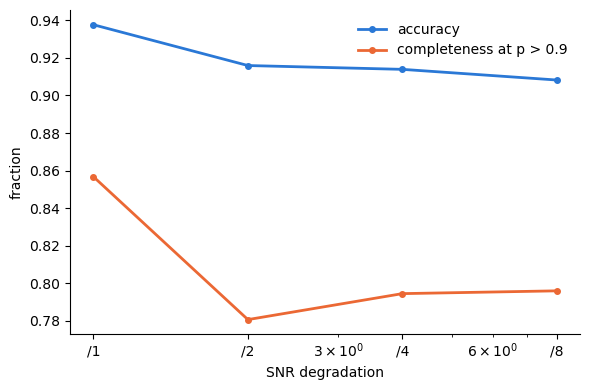

In [11]:
factors = [1, 2, 4, 8]
if FEATURES == "labels":
    print("labels-only features -- spectral noise test not applicable")
else:
    rng = np.random.default_rng(SEED)
    sigma0 = np.where(lab_ivar > 0, 1.0 / np.sqrt(lab_ivar), 0.0)
    rows = []
    for f in factors:
        extra = np.sqrt(max(f ** 2 - 1, 0)) * sigma0
        noisy = lab_flux + rng.standard_normal(lab_flux.shape) * extra
        p_n = np.full(len(y), np.nan)
        pred_n = np.zeros(len(y), dtype=y.dtype)
        for model, (tr, te) in zip(fold_models, splits):
            Xn = classifier_matrix(lab_table.iloc[te], noisy[te],
                                   lab_ivar[te], FEATURES)
            proba = model.predict_proba(Xn)
            cls = np.asarray(model.classes_)
            p_n[te] = proba[:, list(cls).index(TARGET)]
            pred_n[te] = cls[proba.argmax(axis=1)]
        acc_mask = p_n > MIN_PROBA
        rows.append({
            "snr_factor": f,
            "accuracy": float((pred_n == y).mean()),
            "roc_auc": float(roc_auc_score(is_target, p_n)),
            "completeness_at_thresh": float(acc_mask[is_target].mean()),
            "purity_at_thresh": (float((y[acc_mask] == TARGET).mean())
                                 if acc_mask.any() else np.nan),
        })
    degraded = pd.DataFrame(rows)
    display(degraded)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(degraded["snr_factor"], degraded["accuracy"], color=C_HEB,
            lw=2, marker="o", ms=4, label="accuracy")
    ax.plot(degraded["snr_factor"], degraded["completeness_at_thresh"],
            color=C_RGB, lw=2, marker="o", ms=4,
            label=f"completeness at p > {MIN_PROBA}")
    ax.set_xscale("log")
    ax.set_xticks(factors)
    ax.set_xticklabels([f"/{f}" for f in factors])
    ax.set_xlabel("SNR degradation")
    ax.set_ylabel("fraction")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

## 5. Feature-mode comparison

The same folds for all three `--classifier-features` modes. If `spectra` holds
up while `labels` degrades under shift (section 3 can be re-run with
`FEATURES` changed), the spectra-only mode is the safer choice for samples
whose pipeline labels may be systematically offset from APOKASC.

In [12]:
rows = []
for mode in CLASSIFIER_FEATURE_MODES:
    Xm = classifier_matrix(lab_table, lab_flux, lab_ivar, mode)
    pm = cross_val_predict(_make_estimator(mode, n_comp), Xm, y, cv=cv,
                           method="predict_proba")
    pt = pm[:, list(classes).index(TARGET)]
    predm = classes[pm.argmax(axis=1)]
    corr = predm == y
    acc_mask = pt > MIN_PROBA
    rows.append({
        "features": mode,
        "accuracy": float(corr.mean()),
        "roc_auc": float(roc_auc_score(is_target, pt)),
        "clump_box_accuracy": (float(corr[box].mean())
                               if box.any() else np.nan),
        "purity_at_thresh": (float((y[acc_mask] == TARGET).mean())
                             if acc_mask.any() else np.nan),
        "completeness_at_thresh": float(acc_mask[is_target].mean()),
    })
pd.DataFrame(rows)

,features,accuracy,roc_auc,clump_box_accuracy,purity_at_thresh,completeness_at_thresh
0,labels,0.933401,0.977512,0.957670,0.944721,0.844368
1,spectra,0.838782,0.913981,0.838642,0.910741,0.594862
2,both,0.937665,0.977476,0.957670,0.937804,0.856719


## 6. Out-of-support check for a target sample

Distance in the standardized label space from each target star to its five
nearest training neighbors, against the training set's own self-distance
distribution. Stars beyond the training 99th percentile get classified by
extrapolation -- a GBM will still return a confident `p` there, which is
exactly the failure mode the acceptance threshold cannot catch. The
out-of-support fraction is the number to watch for the bulge sample.

2026-07-30 21:54:59,425 [INFO] derived [X/Fe] columns: al_fe, ca_fe, ce_fe, c_fe, co_fe, cr_fe, cu_fe, k_fe, mg_fe, mn_fe, na_fe, nd_fe, ni_fe, n_fe, o_fe, p_fe, si_fe, s_fe, ti_fe, v_fe
INFO:thecannon.train:derived [X/Fe] columns: al_fe, ca_fe, ce_fe, c_fe, co_fe, cr_fe, cu_fe, k_fe, mg_fe, mn_fe, na_fe, nd_fe, ni_fe, n_fe, o_fe, p_fe, si_fe, s_fe, ti_fe, v_fe


94.6% of the target sample lies beyond the training 99th-percentile self-distance (46831 stars with finite labels)


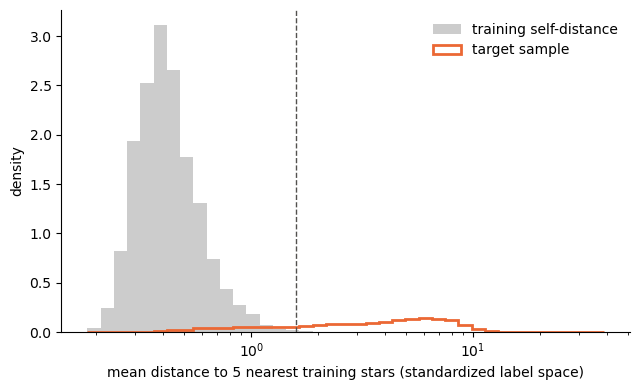

In [13]:
if TARGET_SAMPLE_PATH.exists():
    from sklearn.neighbors import NearestNeighbors
    from sklearn.preprocessing import StandardScaler

    target_table = add_x_fe_columns(pd.read_parquet(TARGET_SAMPLE_PATH))
    L_train = lab_table[EVO_FEATURES].to_numpy(dtype=float)
    L_target = target_table[EVO_FEATURES].to_numpy(dtype=float)
    ok_tr = np.isfinite(L_train).all(axis=1)
    ok_tg = np.isfinite(L_target).all(axis=1)

    scaler = StandardScaler().fit(L_train[ok_tr])
    Z_train = scaler.transform(L_train[ok_tr])
    Z_target = scaler.transform(L_target[ok_tg])

    nn = NearestNeighbors(n_neighbors=6).fit(Z_train)
    d_self = nn.kneighbors(Z_train)[0][:, 1:].mean(axis=1)  # drop self-match
    d_target = nn.kneighbors(Z_target)[0][:, :5].mean(axis=1)
    thresh = float(np.quantile(d_self, 0.99))
    frac_out = float((d_target > thresh).mean())
    print(f"{frac_out:.1%} of the target sample lies beyond the training "
          f"99th-percentile self-distance ({int(ok_tg.sum())} stars with "
          f"finite labels)")

    bins = np.geomspace(
        min(d_self.min(), d_target.min()) + 1e-3,
        max(d_self.max(), d_target.max()), 40)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.hist(d_self, bins=bins, density=True, color="0.8",
            label="training self-distance")
    ax.hist(d_target, bins=bins, density=True, histtype="step",
            color=C_RGB, lw=2, label="target sample")
    ax.axvline(thresh, color=GRAY, ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("mean distance to 5 nearest training stars "
                  "(standardized label space)")
    ax.set_ylabel("density")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
else:
    print(f"no target sample at {TARGET_SAMPLE_PATH} -- skipping")

## Reading the results

- **Section 1**: if clump-box accuracy is far below the global number, the
  headline accuracy is inflated by easy stars -- judge the classifier by the
  box.
- **Section 2**: miscalibration at high `p` means `MIN_PROBA` does not deliver
  the contamination it promises; wrap the estimator in
  `CalibratedClassifierCV` or move the threshold. Large fold spread near the
  threshold argues for averaging a fold ensemble instead of a single fit.
- **Section 3**: the `shifted` vs `random_cv` gap is the extrapolation
  penalty. If the metal-rich holdout collapses, the honest fixes are more
  metal-rich training labels (K2 GAP / TESS seismic samples) rather than a
  higher threshold.
- **Section 4**: fast degradation means low-SNR target stars need train-time
  noise augmentation before their classifications are trustworthy.
- **Section 6**: a large out-of-support fraction means classifications for
  that sample rest on extrapolation regardless of `p`; report the flag in the
  output catalogue and cut on it downstream.